# 03. Interface Damage Model

이번 단계에서는 정상 상태의 신경 기록 인터페이스에
손상이 발생했을 때 기록 신호가 어떻게 변하는지 살펴본다.

관측 신호는

$$
y(s)=h\,x(s)+n(s)
$$

로 정의한다.

여기서

- $x(s)$: 기준 입력 신호
- $n(s)$: 입력에 더해지는 잡음
- $h$: 유효 신호 결합 계수
- $y(s)$: 관측 신호

를 의미한다.

건강한 기준 상태에서는

$$
h=1
$$

로 정의한다.

손상 크기를 $d$라고 하면 단순화된 모델에서

$$
h=1-d
$$

로 둔다.

예를 들어

$$
d=0.5
$$

이면

$$
h=0.5
$$

가 되어 신호 성분의 진폭이 정상 상태의 절반으로 감소한다.

여기서 $h$는 실제 전극 임피던스, 세포 생존율,
피복률 등을 직접 의미하지 않는다.

여러 물리적·생물학적 효과를 하나로 묶은
추상적인 유효 전달 계수이다.

이번 모델은 "손상으로 신호 전달만 약하지고, 잡음 크기는 변하지 않는다."라고 가정한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

n_samples = 512
s = np.arange(n_samples) / n_samples

x = (
    np.sin(2 * np.pi * 7 * s) + 0.35 * np.sin(2 * np.pi * 19 * s)
)

x = x - x.mean()
x = x / np.sqrt(np.mean(x**2))

In [4]:
#잡음

sigma = 0.2

noise = rng.normal(
    loc = 0.0,
    scale=sigma,
    size=n_samples
)

In [5]:
h_healthy = 1.0

y_healthy = h_healthy * x + noise

In [7]:
#손상조건
damage = 0.5

h_damaged = 1.0 - damage

y_damaged = h_damaged * x + noise

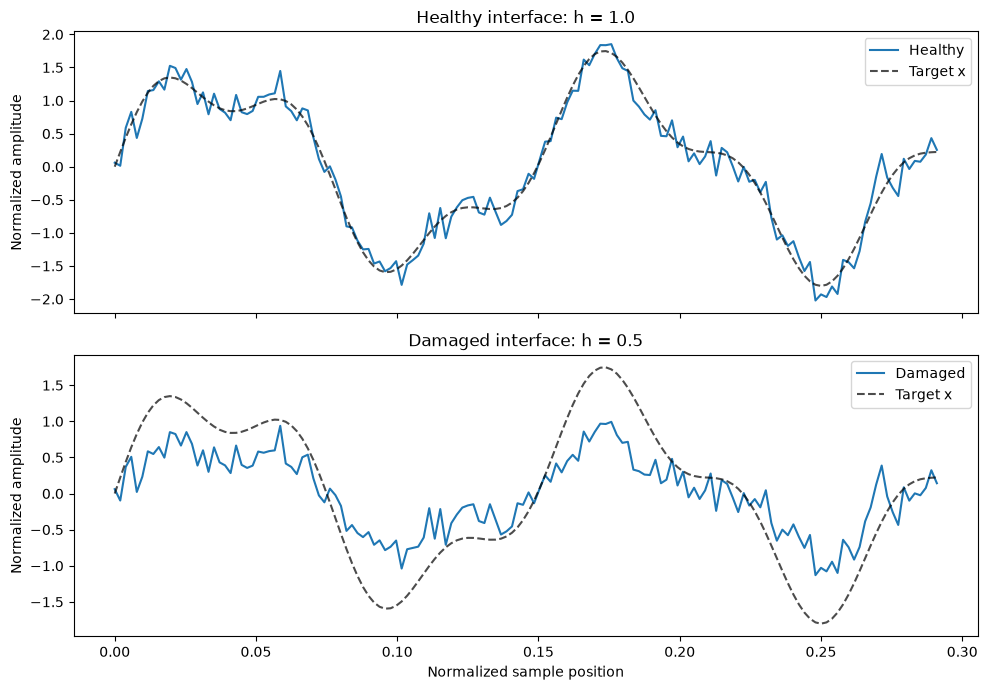

In [8]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True
)

axes[0].plot(
    s[:150],
    y_healthy[:150],
    label="Healthy"
)

axes[0].plot(
    s[:150],
    x[:150],
    "k--",
    alpha=0.7,
    label="Target x"
)

axes[0].set_ylabel("Normalized amplitude")
axes[0].set_title("Healthy interface: h = 1.0")
axes[0].legend()

axes[1].plot(
    s[:150],
    y_damaged[:150],
    label="Damaged"
)

axes[1].plot(
    s[:150],
    x[:150],
    "k--",
    alpha=0.7,
    label="Target x"
)

axes[1].set_xlabel("Normalized sample position")
axes[1].set_ylabel("Normalized amplitude")
axes[1].set_title(f"Damaged interface: h = {h_damaged:.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()